In [894]:
from bs4 import BeautifulSoup
import numpy as np
import re, os, email, json, numbers, pickle, tqdm, time, shutil
import matplotlib.pyplot as plt

path_syn = '../dump/synthesis'
path_test = '../dump/test'
path_dest = '../dump/test/dest'
chunk_size = 140

def to_chunk(text, chunk=100):
    sentences = []
    for sentence in text.split('\n'):
        if len(sentence) == 0:
            continue
        s = []
        for token in re.split(r'( )+', sentence):
            if (len(token) == 1) and (len(token.strip()) == 0):
                continue
            s.append(token)
            if len(' '.join(s)) > chunk:
                sentences.append(' '.join(s))
                s = []
    if len(s) != 0:
        sentences.append(' '.join(s))
    return sentences

def highlight_text(sentences, keys):
    output = []
    pattern = re.compile(r"\x1b\[0m(.{1,3})\x1b\[43m\x1b\[30m")
    for sentence in sentences:
        for k in keys:
            sentence = sentence.replace(k, f'\x1b[43m\x1b[30m{k}\x1b[0m')
        for match in re.finditer(pattern, sentence):
            sentence = sentence.replace(match.group(0), match.group(1))
        output.append(sentence)
    return output

def print_chunk(sentences, f=None):
    for sentence in sentences:
        if f is None:
            print(sentence)
        else:
            f.write(sentence + '\n')
            
with open('/home/jhyang/WORKSPACES/DATA/ICSD_articles/parsed_documents.pkl','rb') as f:
    docs = pickle.load(f)
dois = list(docs.keys())

In [893]:
i = 232
#i = dois.index("10.1016/j.jallcom.2023.171701")
doi = dois[i]
print(f'{i} : https://doi.org/{doi}')
fn = doi.replace('/','%') + '.json'

if os.path.isfile(os.path.join(path_dest, fn)):
    shutil.copyfile(os.path.join(path_dest, fn), os.path.join(path_test, 'test2.json'))
else:
    json.dump([], open(os.path.join(path_test, 'test2.json'),'w'))

with open(os.path.join(path_syn, fn)) as f:
    output_data = json.load(f)
xs = ['solid state','solid-state','solid–state',' h ','hour','temperature','heat','calcin']
for data in output_data:
    for k, v in data.items():
        if k in ['etc', 'responses']: continue
        if isinstance(v, list):
            for x in v:
                if isinstance(x, (int, float)):
                    if x == 0:
                        continue
                    x = f' {x}'                    
                if len(str(x)) < 2:
                    continue
                xs.append(str(x))
        elif isinstance(v, (int, float)):
            if v == 0: 
                continue
            xs.append(f' {v}')
        elif len(str(v)) < 2:
            continue
        else:
            xs.append(str(v))
xs = sorted(np.unique(xs), key=lambda x: len(x), reverse=True)
print(xs)
shutil.copyfile(os.path.join(path_syn, fn), os.path.join(path_test, 'test.json'))

for (_, header), section in docs[doi].items():
    print('='*chunk_size)
    print(f'SECTION: {header}'.center(chunk_size))
    print('='*chunk_size)
    for (_, p) in section:
        sentences = to_chunk(p, chunk=chunk_size)
        sentences = highlight_text(sentences, xs)
        print_chunk(sentences)

IndexError: list index out of range

In [886]:
shutil.copyfile(os.path.join(path_test, 'test.json'), os.path.join(path_dest, fn))

'../dump/test/dest/10.1039%D1QI00879J.json'

In [904]:
path = '/home/jhyang/WORKSPACES/DATA/ICSD_articles/src'
n_articles = 0
for pub in os.listdir(path):
    path_pub = os.path.join(path, pub)
    fns = []
    for fn1 in os.listdir(path_pub):
        if os.path.isfile(os.path.join(path_pub, fn1)):
            fns.append(fn1)
        else:
            for fn2 in os.listdir(os.path.join(path_pub, fn1)):
                fns.append((fn1, fn2))
    print(pub, len(fns))
    n_articles += len(fns)


ACS 75
Elsevier 60
APS 7
MDPI 9
Wiley 34
EJM 1
De Gruyter 3
Springer 9
RSC 28
IUCr 6


In [908]:
targets = []
method = []
n_valid = 0
for fn in os.listdir('../dump/test/dest'):
    try:
        data = json.load(open(f'../dump/test/dest/{fn}'))
        n_valid += 1
    except:
        print(fn)
        continue
    for d in data:
        if 'target' not in d.keys():
            print(fn)
        else:
            targets.append(d['target'])
        if 'method' not in d.keys():
            print(fn)
        else:
            method.append(d['method'])

t, c = np.unique(np.hstack(method), return_counts=True)
n_rxn = np.sum(c)
n_ssr = np.sum(np.hstack(method) == 'solid-state')
print(n_articles, n_valid,'/', n_rxn, n_ssr)

232 110 / 351 294


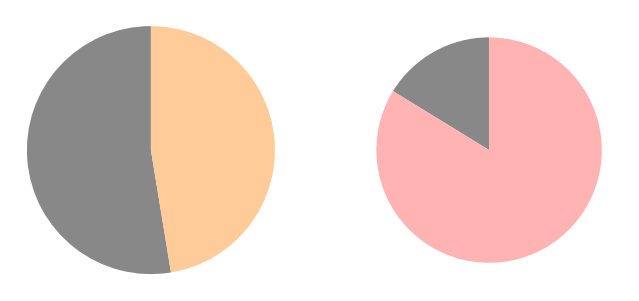

In [909]:
f, axs = plt.subplots(1,2,figsize=(8,5))
axs[0].pie([n_articles-n_valid, n_valid], radius=1.1, startangle=90, colors=['#888888', '#ffcc99'])
axs[1].pie([n_rxn-n_ssr, n_ssr], radius=1, startangle=90, colors=['#888888', '#ffb3b3'])
f.subplots_adjust(hspace=0)